In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
!pip install rasterio --quiet

import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅ GPU Ready: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    print('⚠️ NO GPU! Runtime → Change runtime type → T4 GPU')

print('✅ Cell 1 complete.')

✅ GPU Ready: Tesla T4 (15.6 GB)
✅ Cell 1 complete.


In [2]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================
import os

print('📁 Files in /content/:\n')
for f in sorted(os.listdir('/content/')):
    fp = os.path.join('/content/', f)
    if os.path.isfile(fp):
        print(f'  📄 {f:45s} ({os.path.getsize(fp)/1e6:.1f} MB)')

# ──── PATHS (edit filenames if yours differ) ────
IMG_T1_PATH      = '/content/Aligned_2016_FINAL.tif'
IMG_T2_PATH      = '/content/Aligned_2025_MATCHED.tif'
CHANGE_MASK_PATH = '/content/change_mask.tif'
TRAINING_CSV     = '/content/training_data.csv'
OUTPUT_DIR       = '/content/outputs_siamese'

# ──── TRAINING SETTINGS ────
PATCH_SIZE  = 256
STRIDE      = 128
BATCH_SIZE  = 8      # Reduce to 4 if CUDA OOM
EPOCHS      = 100
LR          = 1e-4
NUM_BANDS   = 3      # 3=RGB, 4=RGB+NIR
NUM_WORKERS = 2

# ──── WHICH SIAMESE MODEL TO USE ────
# Options: 'SNUNet-ECAM' or 'SiamUNet-diff'
MODEL_CHOICE = 'SNUNet-ECAM'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('\n── File check ──')
all_ok = True
for name, path in [('T1 Image', IMG_T1_PATH), ('T2 Image', IMG_T2_PATH),
                    ('Change Mask', CHANGE_MASK_PATH), ('Training CSV', TRAINING_CSV)]:
    exists = os.path.exists(path)
    print(f'  {"✅" if exists else "❌"} {name}: {os.path.basename(path)}')
    if not exists: all_ok = False

print(f'\n  Model: {MODEL_CHOICE}')
print('\n✅ All files found!' if all_ok else '\n❌ Missing files! Check paths above.')

📁 Files in /content/:

  📄 Aligned_2016_FINAL.tif                        (36.1 MB)
  📄 Aligned_2025_MATCHED.tif                      (36.1 MB)
  📄 change_mask.tif                               (48.1 MB)
  📄 training_data.csv                             (0.0 MB)

── File check ──
  ✅ T1 Image: Aligned_2016_FINAL.tif
  ✅ T2 Image: Aligned_2025_MATCHED.tif
  ✅ Change Mask: change_mask.tif
  ✅ Training CSV: training_data.csv

  Model: SNUNet-ECAM

✅ All files found!


In [3]:
# ============================================================
# CELL 3: SIAMESE UNET MODELS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.modules.padding import ReplicationPad2d


# ── Building blocks ──

class conv_block_nested(nn.Module):
    def __init__(self, in_ch, mid_ch, out_ch):
        super().__init__()
        self.activation = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=True)
        self.bn1 = nn.BatchNorm2d(mid_ch)
        self.conv2 = nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=True)
        self.bn2 = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = self.conv1(x)
        identity = x
        x = self.activation(self.bn1(x))
        x = self.conv2(x)
        x = self.bn2(x)
        return self.activation(x + identity)


class up_block(nn.Module):
    def __init__(self, in_ch, bilinear=False):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2)

    def forward(self, x):
        return self.up(x)


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_channels, in_channels // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_channels // ratio, in_channels, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        mx  = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg + mx)


# ══════════════════════════════════════════════════════════════
# MODEL 1: SNUNet-ECAM (Siamese Nested UNet + Channel Attention)
# ══════════════════════════════════════════════════════════════

class SNUNet_ECAM(nn.Module):
    """
    Siamese Nested UNet with Ensemble Channel Attention.
    Input:  xA (B,3,H,W), xB (B,3,H,W)  — T1 and T2 images
    Output: (B, out_ch, H, W)             — change logits
    """

    def __init__(self, in_ch=3, out_ch=2):
        super().__init__()
        n1 = 32
        f = [n1, n1*2, n1*4, n1*8, n1*16]

        self.pool = nn.MaxPool2d(2, 2)

        # Encoder (shared weights for both temporal inputs)
        self.conv0_0 = conv_block_nested(in_ch, f[0], f[0])
        self.conv1_0 = conv_block_nested(f[0], f[1], f[1])
        self.Up1_0   = up_block(f[1])
        self.conv2_0 = conv_block_nested(f[1], f[2], f[2])
        self.Up2_0   = up_block(f[2])
        self.conv3_0 = conv_block_nested(f[2], f[3], f[3])
        self.Up3_0   = up_block(f[3])
        self.conv4_0 = conv_block_nested(f[3], f[4], f[4])
        self.Up4_0   = up_block(f[4])

        # Nested decoder
        self.conv0_1 = conv_block_nested(f[0]*2 + f[1], f[0], f[0])
        self.conv1_1 = conv_block_nested(f[1]*2 + f[2], f[1], f[1])
        self.Up1_1   = up_block(f[1])
        self.conv2_1 = conv_block_nested(f[2]*2 + f[3], f[2], f[2])
        self.Up2_1   = up_block(f[2])
        self.conv3_1 = conv_block_nested(f[3]*2 + f[4], f[3], f[3])
        self.Up3_1   = up_block(f[3])

        self.conv0_2 = conv_block_nested(f[0]*3 + f[1], f[0], f[0])
        self.conv1_2 = conv_block_nested(f[1]*3 + f[2], f[1], f[1])
        self.Up1_2   = up_block(f[1])
        self.conv2_2 = conv_block_nested(f[2]*3 + f[3], f[2], f[2])
        self.Up2_2   = up_block(f[2])

        self.conv0_3 = conv_block_nested(f[0]*4 + f[1], f[0], f[0])
        self.conv1_3 = conv_block_nested(f[1]*4 + f[2], f[1], f[1])
        self.Up1_3   = up_block(f[1])

        self.conv0_4 = conv_block_nested(f[0]*5 + f[1], f[0], f[0])

        # Ensemble Channel Attention
        self.ca  = ChannelAttention(f[0]*4, ratio=16)
        self.ca1 = ChannelAttention(f[0], ratio=16//4)
        self.conv_final = nn.Conv2d(f[0]*4, out_ch, 1)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, xA, xB):
        # Encoder stream A (T1 = 2016)
        x0_0A = self.conv0_0(xA)
        x1_0A = self.conv1_0(self.pool(x0_0A))
        x2_0A = self.conv2_0(self.pool(x1_0A))
        x3_0A = self.conv3_0(self.pool(x2_0A))

        # Encoder stream B (T2 = 2025)
        x0_0B = self.conv0_0(xB)
        x1_0B = self.conv1_0(self.pool(x0_0B))
        x2_0B = self.conv2_0(self.pool(x1_0B))
        x3_0B = self.conv3_0(self.pool(x2_0B))
        x4_0B = self.conv4_0(self.pool(x3_0B))

        # Nested decoder with dense skip connections
        x0_1 = self.conv0_1(torch.cat([x0_0A, x0_0B, self.Up1_0(x1_0B)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0A, x1_0B, self.Up2_0(x2_0B)], 1))
        x0_2 = self.conv0_2(torch.cat([x0_0A, x0_0B, x0_1, self.Up1_1(x1_1)], 1))

        x2_1 = self.conv2_1(torch.cat([x2_0A, x2_0B, self.Up3_0(x3_0B)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0A, x1_0B, x1_1, self.Up2_1(x2_1)], 1))
        x0_3 = self.conv0_3(torch.cat([x0_0A, x0_0B, x0_1, x0_2, self.Up1_2(x1_2)], 1))

        x3_1 = self.conv3_1(torch.cat([x3_0A, x3_0B, self.Up4_0(x4_0B)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0A, x2_0B, x2_1, self.Up3_1(x3_1)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0A, x1_0B, x1_1, x1_2, self.Up2_2(x2_2)], 1))
        x0_4 = self.conv0_4(torch.cat([x0_0A, x0_0B, x0_1, x0_2, x0_3, self.Up1_3(x1_3)], 1))

        # ECAM fusion
        out = torch.cat([x0_1, x0_2, x0_3, x0_4], 1)
        intra = torch.sum(torch.stack((x0_1, x0_2, x0_3, x0_4)), dim=0)
        ca1 = self.ca1(intra)
        out = self.ca(out) * (out + ca1.repeat(1, 4, 1, 1))
        return self.conv_final(out)


# ══════════════════════════════════════════════════════════════
# MODEL 2: SiamUNet-diff (Feature Difference Siamese UNet)
# ══════════════════════════════════════════════════════════════

class SiamUnet_diff(nn.Module):
    """
    Siamese UNet with feature differencing at skip connections.
    Input:  x1 (B,3,H,W), x2 (B,3,H,W)
    Output: (B, label_nbr, H, W)
    """

    def __init__(self, input_nbr=3, label_nbr=2):
        super().__init__()
        n1 = 16
        f = [n1, n1*2, n1*4, n1*8, n1*16]

        # Encoder
        self.conv11 = nn.Conv2d(input_nbr,f[0],3,padding=1); self.bn11 = nn.BatchNorm2d(f[0]); self.do11 = nn.Dropout2d(0.2)
        self.conv12 = nn.Conv2d(f[0],f[0],3,padding=1);     self.bn12 = nn.BatchNorm2d(f[0]); self.do12 = nn.Dropout2d(0.2)

        self.conv21 = nn.Conv2d(f[0],f[1],3,padding=1); self.bn21 = nn.BatchNorm2d(f[1]); self.do21 = nn.Dropout2d(0.2)
        self.conv22 = nn.Conv2d(f[1],f[1],3,padding=1); self.bn22 = nn.BatchNorm2d(f[1]); self.do22 = nn.Dropout2d(0.2)

        self.conv31 = nn.Conv2d(f[1],f[2],3,padding=1); self.bn31 = nn.BatchNorm2d(f[2]); self.do31 = nn.Dropout2d(0.2)
        self.conv32 = nn.Conv2d(f[2],f[2],3,padding=1); self.bn32 = nn.BatchNorm2d(f[2]); self.do32 = nn.Dropout2d(0.2)
        self.conv33 = nn.Conv2d(f[2],f[2],3,padding=1); self.bn33 = nn.BatchNorm2d(f[2]); self.do33 = nn.Dropout2d(0.2)

        self.conv41 = nn.Conv2d(f[2],f[3],3,padding=1); self.bn41 = nn.BatchNorm2d(f[3]); self.do41 = nn.Dropout2d(0.2)
        self.conv42 = nn.Conv2d(f[3],f[3],3,padding=1); self.bn42 = nn.BatchNorm2d(f[3]); self.do42 = nn.Dropout2d(0.2)
        self.conv43 = nn.Conv2d(f[3],f[3],3,padding=1); self.bn43 = nn.BatchNorm2d(f[3]); self.do43 = nn.Dropout2d(0.2)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(f[3],f[3],3,padding=1,stride=2,output_padding=1)
        self.conv43d = nn.ConvTranspose2d(f[4],f[3],3,padding=1); self.bn43d = nn.BatchNorm2d(f[3]); self.do43d = nn.Dropout2d(0.2)
        self.conv42d = nn.ConvTranspose2d(f[3],f[3],3,padding=1); self.bn42d = nn.BatchNorm2d(f[3]); self.do42d = nn.Dropout2d(0.2)
        self.conv41d = nn.ConvTranspose2d(f[3],f[2],3,padding=1); self.bn41d = nn.BatchNorm2d(f[2]); self.do41d = nn.Dropout2d(0.2)

        self.upconv3 = nn.ConvTranspose2d(f[2],f[2],3,padding=1,stride=2,output_padding=1)
        self.conv33d = nn.ConvTranspose2d(f[3],f[2],3,padding=1); self.bn33d = nn.BatchNorm2d(f[2]); self.do33d = nn.Dropout2d(0.2)
        self.conv32d = nn.ConvTranspose2d(f[2],f[2],3,padding=1); self.bn32d = nn.BatchNorm2d(f[2]); self.do32d = nn.Dropout2d(0.2)
        self.conv31d = nn.ConvTranspose2d(f[2],f[1],3,padding=1); self.bn31d = nn.BatchNorm2d(f[1]); self.do31d = nn.Dropout2d(0.2)

        self.upconv2 = nn.ConvTranspose2d(f[1],f[1],3,padding=1,stride=2,output_padding=1)
        self.conv22d = nn.ConvTranspose2d(f[2],f[1],3,padding=1); self.bn22d = nn.BatchNorm2d(f[1]); self.do22d = nn.Dropout2d(0.2)
        self.conv21d = nn.ConvTranspose2d(f[1],f[0],3,padding=1); self.bn21d = nn.BatchNorm2d(f[0]); self.do21d = nn.Dropout2d(0.2)

        self.upconv1 = nn.ConvTranspose2d(f[0],f[0],3,padding=1,stride=2,output_padding=1)
        self.conv12d = nn.ConvTranspose2d(f[1],f[0],3,padding=1); self.bn12d = nn.BatchNorm2d(f[0]); self.do12d = nn.Dropout2d(0.2)
        self.conv11d = nn.ConvTranspose2d(f[0], label_nbr, 3, padding=1)

    def _encode(self, x):
        """Shared encoder — same weights for T1 and T2."""
        x11 = self.do11(F.relu(self.bn11(self.conv11(x))))
        x12 = self.do12(F.relu(self.bn12(self.conv12(x11))))
        x1p = F.max_pool2d(x12, 2, 2)

        x21 = self.do21(F.relu(self.bn21(self.conv21(x1p))))
        x22 = self.do22(F.relu(self.bn22(self.conv22(x21))))
        x2p = F.max_pool2d(x22, 2, 2)

        x31 = self.do31(F.relu(self.bn31(self.conv31(x2p))))
        x32 = self.do32(F.relu(self.bn32(self.conv32(x31))))
        x33 = self.do33(F.relu(self.bn33(self.conv33(x32))))
        x3p = F.max_pool2d(x33, 2, 2)

        x41 = self.do41(F.relu(self.bn41(self.conv41(x3p))))
        x42 = self.do42(F.relu(self.bn42(self.conv42(x41))))
        x43 = self.do43(F.relu(self.bn43(self.conv43(x42))))
        x4p = F.max_pool2d(x43, 2, 2)

        return x12, x22, x33, x43, x4p

    def forward(self, x1, x2):
        # Encode both temporal inputs with shared weights
        x12_1, x22_1, x33_1, x43_1, x4p = self._encode(x1)
        x12_2, x22_2, x33_2, x43_2, _    = self._encode(x2)

        # Decoder with feature DIFFERENCES at skip connections
        x4d = self.upconv4(x4p)
        pad4 = ReplicationPad2d((0, x43_1.size(3)-x4d.size(3), 0, x43_1.size(2)-x4d.size(2)))
        x4d = torch.cat((pad4(x4d), torch.abs(x43_1 - x43_2)), 1)
        x43d = self.do43d(F.relu(self.bn43d(self.conv43d(x4d))))
        x42d = self.do42d(F.relu(self.bn42d(self.conv42d(x43d))))
        x41d = self.do41d(F.relu(self.bn41d(self.conv41d(x42d))))

        x3d = self.upconv3(x41d)
        pad3 = ReplicationPad2d((0, x33_1.size(3)-x3d.size(3), 0, x33_1.size(2)-x3d.size(2)))
        x3d = torch.cat((pad3(x3d), torch.abs(x33_1 - x33_2)), 1)
        x33d = self.do33d(F.relu(self.bn33d(self.conv33d(x3d))))
        x32d = self.do32d(F.relu(self.bn32d(self.conv32d(x33d))))
        x31d = self.do31d(F.relu(self.bn31d(self.conv31d(x32d))))

        x2d = self.upconv2(x31d)
        pad2 = ReplicationPad2d((0, x22_1.size(3)-x2d.size(3), 0, x22_1.size(2)-x2d.size(2)))
        x2d = torch.cat((pad2(x2d), torch.abs(x22_1 - x22_2)), 1)
        x22d = self.do22d(F.relu(self.bn22d(self.conv22d(x2d))))
        x21d = self.do21d(F.relu(self.bn21d(self.conv21d(x22d))))

        x1d = self.upconv1(x21d)
        pad1 = ReplicationPad2d((0, x12_1.size(3)-x1d.size(3), 0, x12_1.size(2)-x1d.size(2)))
        x1d = torch.cat((pad1(x1d), torch.abs(x12_1 - x12_2)), 1)
        x12d = self.do12d(F.relu(self.bn12d(self.conv12d(x1d))))
        return self.conv11d(x12d)


# ── Build selected model ──
if MODEL_CHOICE == 'SNUNet-ECAM':
    model = SNUNet_ECAM(in_ch=NUM_BANDS, out_ch=2)
else:
    model = SiamUnet_diff(input_nbr=NUM_BANDS, label_nbr=2)

params = sum(p.numel() for p in model.parameters())
print(f'✅ {MODEL_CHOICE} | Parameters: {params:,}')

✅ SNUNet-ECAM | Parameters: 12,034,978


In [4]:
# ============================================================
# CELL 4: DATASET, LOSS, METRICS
# ============================================================

import numpy as np
import pandas as pd
import time, json
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score


def load_geotiff(path):
    """Load GeoTIFF → numpy array + metadata."""
    meta = None
    try:
        import rasterio
        with rasterio.open(path) as src:
            data = src.read().astype(np.float32)
            meta = src.meta.copy()
        print(f'  Loaded: {os.path.basename(path)}  shape={data.shape}')
        return data, meta
    except Exception as e:
        print(f'  rasterio failed ({e}), trying PIL...')
        img = Image.open(path)
        data = np.array(img).astype(np.float32)
        if data.ndim == 3:
            data = data.transpose(2, 0, 1)
        print(f'  Loaded (PIL): {os.path.basename(path)}  shape={data.shape}')
        return data, meta


def save_geotiff(path, data, ref=None):
    """Save array as GeoTIFF."""
    try:
        import rasterio
        if ref:
            m = ref.copy()
            m.update(count=1, dtype='float32', compress='lzw')
            with rasterio.open(path, 'w', **m) as d:
                d.write(data.astype(np.float32), 1)
            return
    except Exception:
        pass
    Image.fromarray(data.astype(np.float32)).save(path)


class ChangeDetectionDataset(Dataset):
    """
    Returns SEPARATE T1 and T2 patches for Siamese models.
    x1: (3, H, W) = T1 patch
    x2: (3, H, W) = T2 patch
    y:  (1, H, W) = change mask
    """

    def __init__(self, t1, t2, mask, coords, ps, augment=False):
        self.t1, self.t2, self.mask = t1, t2, mask
        self.coords, self.ps, self.aug = coords, ps, augment

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        r, c = self.coords[idx]
        ps = self.ps

        p1 = self.t1[:, r:r+ps, c:c+ps].copy()
        p2 = self.t2[:, r:r+ps, c:c+ps].copy()
        m  = self.mask[r:r+ps, c:c+ps].copy()

        if self.aug:
            p1, p2, m = self._augment(p1, p2, m)

        return (torch.from_numpy(p1.copy()).float(),
                torch.from_numpy(p2.copy()).float(),
                torch.from_numpy(m[None].copy()).float())

    @staticmethod
    def _augment(t1, t2, m):
        # Horizontal flip
        if np.random.rand() > 0.5:
            t1, t2, m = t1[:,:,::-1], t2[:,:,::-1], m[:,::-1]
        # Vertical flip
        if np.random.rand() > 0.5:
            t1, t2, m = t1[:,::-1,:], t2[:,::-1,:], m[::-1,:]
        # Random 90° rotation
        k = np.random.randint(0, 4)
        if k:
            t1 = np.rot90(t1, k, (1,2)).copy()
            t2 = np.rot90(t2, k, (1,2)).copy()
            m  = np.rot90(m, k, (0,1)).copy()
        # Brightness jitter
        if np.random.rand() > 0.5:
            f = np.random.uniform(0.9, 1.1)
            t1 = np.clip(t1 * f, 0, 1)
            t2 = np.clip(t2 * f, 0, 1)
        return t1, t2, m


def extract_patches(h, w, ps, stride, mask=None):
    coords = []
    for r in range(0, h - ps + 1, stride):
        for c in range(0, w - ps + 1, stride):
            if mask is not None and not np.isfinite(mask[r:r+ps, c:c+ps]).any():
                continue
            coords.append((r, c))
    return coords


def spatial_split(coords, w, ps, test_frac=0.2):
    split_col = int(w * (1 - test_frac))
    train = [(r,c) for r,c in coords if c + ps <= split_col]
    test  = [(r,c) for r,c in coords if c >= split_col]
    if len(test) < 5 or len(train) < 5:
        train, test = train_test_split(coords, test_size=test_frac, random_state=42)
        print('  ⚠️ Fell back to random split')
    print(f'  Train: {len(train)} patches | Test: {len(test)} patches')
    return train, test


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, pos_weight=2.67, smooth=1.0):
        super().__init__()
        self.bce_w = bce_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        self.smooth = smooth

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        p = torch.sigmoid(logits)
        inter = (p * targets).sum()
        dice = 1 - (2*inter + self.smooth) / (p.sum() + targets.sum() + self.smooth)
        return self.bce_w * bce + (1 - self.bce_w) * dice


class Metrics:
    def __init__(self, thr=0.5):
        self.thr = thr
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0

    @torch.no_grad()
    def update(self, logits, targets):
        p = (torch.sigmoid(logits) > self.thr).float()
        t = targets.float()
        self.tp += ((p==1) & (t==1)).sum().item()
        self.fp += ((p==1) & (t==0)).sum().item()
        self.fn += ((p==0) & (t==1)).sum().item()
        self.tn += ((p==0) & (t==0)).sum().item()

    @property
    def precision(self):
        return self.tp/(self.tp+self.fp) if self.tp+self.fp else 0
    @property
    def recall(self):
        return self.tp/(self.tp+self.fn) if self.tp+self.fn else 0
    @property
    def f1(self):
        p, r = self.precision, self.recall
        return 2*p*r/(p+r) if p+r else 0
    @property
    def iou(self):
        d = self.tp+self.fp+self.fn
        return self.tp/d if d else 0
    @property
    def oa(self):
        t = self.tp+self.fp+self.fn+self.tn
        return (self.tp+self.tn)/t if t else 0
    @property
    def kappa(self):
        tot = self.tp+self.fp+self.fn+self.tn
        if not tot: return 0
        po = (self.tp+self.tn)/tot
        pe = ((self.tp+self.fp)*(self.tp+self.fn) + (self.tn+self.fn)*(self.tn+self.fp)) / (tot*tot)
        return (po-pe)/(1-pe) if (1-pe) else 0


print('✅ Cell 4 complete.')

✅ Cell 4 complete.


In [5]:
# ============================================================
# CELL 5: LOAD DATA & BUILD DATALOADERS
# ============================================================

print('Loading imagery...')
img_t1, meta_t1 = load_geotiff(IMG_T1_PATH)
img_t2, meta_t2 = load_geotiff(IMG_T2_PATH)
mask, meta_mask  = load_geotiff(CHANGE_MASK_PATH)

# Select bands
nb = NUM_BANDS
if img_t1.ndim == 3 and img_t1.shape[0] > nb: img_t1 = img_t1[:nb]
if img_t2.ndim == 3 and img_t2.shape[0] > nb: img_t2 = img_t2[:nb]
if mask.ndim == 3: mask = mask[0]

# Clean NoData
mask[mask <= -3.4e+38] = 0
mask = np.clip(mask, 0, 1)

# Normalize to [0, 1]
img_t1 = img_t1 / max(img_t1.max(), 1)
img_t2 = img_t2 / max(img_t2.max(), 1)

_, H, W = img_t1.shape
print(f'\n  T1: {img_t1.shape}  |  T2: {img_t2.shape}  |  Mask: {mask.shape}')
print(f'  Coverage: {H*3/1000:.1f}km × {W*3/1000:.1f}km')
print(f'  Change pixels: {mask.sum():.0f} ({mask.mean()*100:.1f}%)')

assert img_t1.shape[1:] == img_t2.shape[1:] == mask.shape, \
    f'❌ Shape mismatch! T1={img_t1.shape} T2={img_t2.shape} Mask={mask.shape}'

# Extract patches
print(f'\nExtracting {PATCH_SIZE}×{PATCH_SIZE} patches (stride={STRIDE})...')
all_coords = extract_patches(H, W, PATCH_SIZE, STRIDE, mask)
print(f'  Total patches: {len(all_coords)}')

train_coords, test_coords = spatial_split(all_coords, W, PATCH_SIZE)

# Compute class balance
change_px = sum(mask[r:r+PATCH_SIZE, c:c+PATCH_SIZE].sum() for r,c in train_coords)
total_px = len(train_coords) * PATCH_SIZE**2
change_ratio = change_px / max(total_px, 1)
POS_WEIGHT = (1 - change_ratio) / max(change_ratio, 1e-6)
print(f'  Change ratio: {change_ratio*100:.1f}% → pos_weight={POS_WEIGHT:.2f}')

# Build dataloaders
train_ds = ChangeDetectionDataset(img_t1, img_t2, mask, train_coords, PATCH_SIZE, augment=True)
test_ds  = ChangeDetectionDataset(img_t1, img_t2, mask, test_coords, PATCH_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'  Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# Spectral signature check
if os.path.exists(TRAINING_CSV):
    df = pd.read_csv(TRAINING_CSV)
    CLASS_NAMES = {1: 'Buildings', 2: 'Vegetation', 3: 'Water'}
    print(f'\n  Spectral signatures ({len(df)} samples):')
    for cid in sorted(df['class_id'].unique()):
        s = df[df['class_id'] == cid]
        print(f'    {CLASS_NAMES.get(cid, f"C{cid}"):>12}: '
              f'R={s.SAMPLE_1.mean():.0f} G={s.SAMPLE_2.mean():.0f} '
              f'B={s.SAMPLE_3.mean():.0f} (n={len(s)})')

print('\n✅ Data ready.')

Loading imagery...
  Loaded: Aligned_2016_FINAL.tif  shape=(3, 3389, 3544)
  Loaded: Aligned_2025_MATCHED.tif  shape=(3, 3389, 3544)
  Loaded: change_mask.tif  shape=(1, 3389, 3544)

  T1: (3, 3389, 3544)  |  T2: (3, 3389, 3544)  |  Mask: (3389, 3544)
  Coverage: 10.2km × 10.6km
  Change pixels: 3274677 (27.3%)

Extracting 256×256 patches (stride=128)...
  Total patches: 650
  Train: 525 patches | Test: 75 patches
  Change ratio: 26.8% → pos_weight=2.73
  Train batches: 65 | Test batches: 10

  Spectral signatures (76 samples):
       Buildings: R=111 G=113 B=117 (n=39)
      Vegetation: R=38 G=60 B=41 (n=24)
           Water: R=85 G=119 B=137 (n=13)

✅ Data ready.


In [6]:
# ============================================================
# CELL 6: TRAINING
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f'Device: {device}')
print(f'Model: {MODEL_CHOICE} | Params: {sum(p.numel() for p in model.parameters()):,}')

criterion = BCEDiceLoss(bce_weight=0.5, pos_weight=POS_WEIGHT).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

train_m, val_m = Metrics(), Metrics()
best_f1, patience, EARLY_STOP = 0.0, 0, 15
history = []
ckpt_path = os.path.join(OUTPUT_DIR, 'best_siamese_unet.pth')

print(f'\n{"═"*70}')
print(f'  TRAINING — {MODEL_CHOICE} | {EPOCHS} epochs | batch={BATCH_SIZE} | lr={LR}')
print(f'{"═"*70}\n')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──
    model.train()
    train_m.reset()
    tloss = 0

    for xA, xB, y in train_loader:
        xA, xB, y = xA.to(device), xB.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(xA, xB)

        # Handle tuple output
        if isinstance(logits, tuple):
            logits = logits[0]
        # Take change channel if 2-class output
        if logits.shape[1] == 2:
            logits = logits[:, 1:2]

        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        tloss += loss.item()
        train_m.update(logits, y)

    tloss /= max(len(train_loader), 1)

    # ── Validate ──
    model.eval()
    val_m.reset()
    vloss = 0

    with torch.no_grad():
        for xA, xB, y in test_loader:
            xA, xB, y = xA.to(device), xB.to(device), y.to(device)

            logits = model(xA, xB)
            if isinstance(logits, tuple):
                logits = logits[0]
            if logits.shape[1] == 2:
                logits = logits[:, 1:2]

            vloss += criterion(logits, y).item()
            val_m.update(logits, y)

    vloss /= max(len(test_loader), 1)
    scheduler.step()

    # ── Log ──
    elapsed = time.time() - t0
    marker = ''
    if val_m.f1 > best_f1:
        best_f1 = val_m.f1
        patience = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_f1': best_f1,
        }, ckpt_path)
        marker = ' ★'
    else:
        patience += 1

    print(f'Ep {epoch:03d}/{EPOCHS} | loss={tloss:.4f}/{vloss:.4f} | '
          f'F1={val_m.f1:.4f} IoU={val_m.iou:.4f} K={val_m.kappa:.4f} | '
          f'{elapsed:.0f}s{marker}')

    history.append({
        'epoch': epoch, 'train_loss': round(tloss, 5),
        'val_loss': round(vloss, 5), 'val_f1': round(val_m.f1, 4),
        'val_iou': round(val_m.iou, 4), 'val_kappa': round(val_m.kappa, 4)
    })

    if patience >= EARLY_STOP:
        print(f'\n⏹️ Early stopping at epoch {epoch}')
        break

# Save history
with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print(f'\n✅ Training complete. Best F1 = {best_f1:.4f}')

Device: cuda
Model: SNUNet-ECAM | Params: 12,034,978

══════════════════════════════════════════════════════════════════════
  TRAINING — SNUNet-ECAM | 100 epochs | batch=8 | lr=0.0001
══════════════════════════════════════════════════════════════════════

Ep 001/100 | loss=1.6519/0.8416 | F1=0.7392 IoU=0.5863 K=0.5634 | 50s ★
Ep 002/100 | loss=0.9384/0.7055 | F1=0.7638 IoU=0.6179 K=0.6068 | 50s ★
Ep 003/100 | loss=0.7550/0.6250 | F1=0.7776 IoU=0.6361 K=0.6359 | 53s ★
Ep 004/100 | loss=0.6484/0.5331 | F1=0.8072 IoU=0.6768 K=0.6889 | 52s ★
Ep 005/100 | loss=0.5831/0.5475 | F1=0.8024 IoU=0.6700 K=0.6931 | 53s
Ep 006/100 | loss=0.5351/0.4301 | F1=0.8280 IoU=0.7065 K=0.7110 | 53s ★
Ep 007/100 | loss=0.4873/0.4261 | F1=0.8208 IoU=0.6961 K=0.6950 | 53s
Ep 008/100 | loss=0.4754/0.4158 | F1=0.8270 IoU=0.7051 K=0.7058 | 53s
Ep 009/100 | loss=0.4537/0.4194 | F1=0.8265 IoU=0.7042 K=0.7045 | 53s
Ep 010/100 | loss=0.4244/0.3885 | F1=0.8292 IoU=0.7082 K=0.7095 | 53s ★
Ep 011/100 | loss=0.4034/0.3734

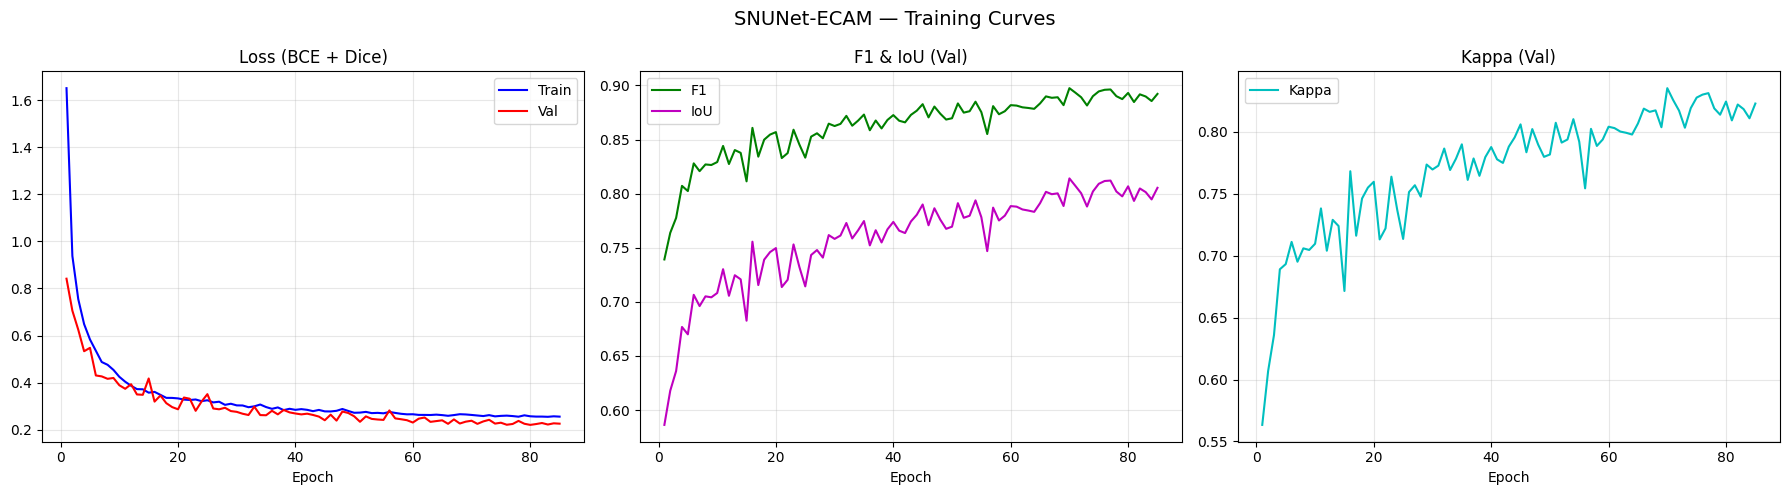

In [7]:
# ============================================================
# CELL 7: TRAINING CURVES
# ============================================================
import matplotlib.pyplot as plt

ep = [h['epoch'] for h in history]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(ep, [h['train_loss'] for h in history], 'b-', label='Train')
ax[0].plot(ep, [h['val_loss'] for h in history], 'r-', label='Val')
ax[0].set_title('Loss (BCE + Dice)'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ep, [h['val_f1'] for h in history], 'g-', label='F1')
ax[1].plot(ep, [h['val_iou'] for h in history], 'm-', label='IoU')
ax[1].set_title('F1 & IoU (Val)'); ax[1].legend(); ax[1].grid(alpha=0.3)

ax[2].plot(ep, [h['val_kappa'] for h in history], 'c-', label='Kappa')
ax[2].set_title('Kappa (Val)'); ax[2].legend(); ax[2].grid(alpha=0.3)

for a in ax: a.set_xlabel('Epoch')
plt.suptitle(f'{MODEL_CHOICE} — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [8]:
# ============================================================
# CELL 8: GENERATE FULL CHANGE MAP
# ============================================================

# Load best checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best model (epoch {ckpt["epoch"]}, F1={ckpt["best_f1"]:.4f})')

# Sliding window inference
print('Generating change map...')
_, H, W = img_t1.shape
inf_stride = STRIDE // 2

prob_map  = np.zeros((H, W), dtype=np.float64)
count_map = np.zeros((H, W), dtype=np.float64)

n_r = len(range(0, H - PATCH_SIZE + 1, inf_stride))
n_c = len(range(0, W - PATCH_SIZE + 1, inf_stride))
total = n_r * n_c
done = 0

with torch.no_grad():
    for r in range(0, H - PATCH_SIZE + 1, inf_stride):
        for c in range(0, W - PATCH_SIZE + 1, inf_stride):
            p1 = img_t1[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
            p2 = img_t2[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]

            xA = torch.from_numpy(p1).float().unsqueeze(0).to(device)
            xB = torch.from_numpy(p2).float().unsqueeze(0).to(device)

            logits = model(xA, xB)
            if isinstance(logits, tuple):
                logits = logits[0]
            if logits.shape[1] == 2:
                logits = logits[:, 1:2]

            probs = torch.sigmoid(logits).cpu().numpy()[0, 0]
            prob_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE]  += probs
            count_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1.0

            done += 1
            if done % 200 == 0:
                print(f'  {done}/{total} ({done/total*100:.0f}%)', end='\r')

prob_map /= np.maximum(count_map, 1.0)
binary_map = (prob_map > 0.5).astype(np.uint8)

# Save
save_geotiff(os.path.join(OUTPUT_DIR, 'change_probability.tif'), prob_map, meta_mask)
save_geotiff(os.path.join(OUTPUT_DIR, 'change_prediction.tif'),
             binary_map.astype(np.float32), meta_mask)

print(f'\n\n✅ Change map saved!')
print(f'   Changed: {binary_map.sum()*9/10000:.1f} ha ({binary_map.mean()*100:.1f}%)')

Loaded best model (epoch 70, F1=0.8975)
Generating change map...


✅ Change map saved!
   Changed: 3310.3 ha (30.6%)


╔═══════════════════════════════════════════════════════╗
║    FINAL RESULTS —     SNUNet-ECAM                 ║
╠═══════════════════════════════════════════════════════╣
║  Precision        : 0.7930                          ║
║  Recall           : 0.8907                          ║
║  F1-Score         : 0.8390                          ║
║  IoU              : 0.7226                          ║
║  Overall Accuracy : 0.9068                          ║
║  Kappa Coefficient: 0.7737                          ║
╠═══════════════════════════════════════════════════════╣
║  Changed area     :    3,310.3 ha                ║
║  Total area       :   10,809.6 ha                ║
║  Change %         :       30.6%                 ║
╚═══════════════════════════════════════════════════════╝


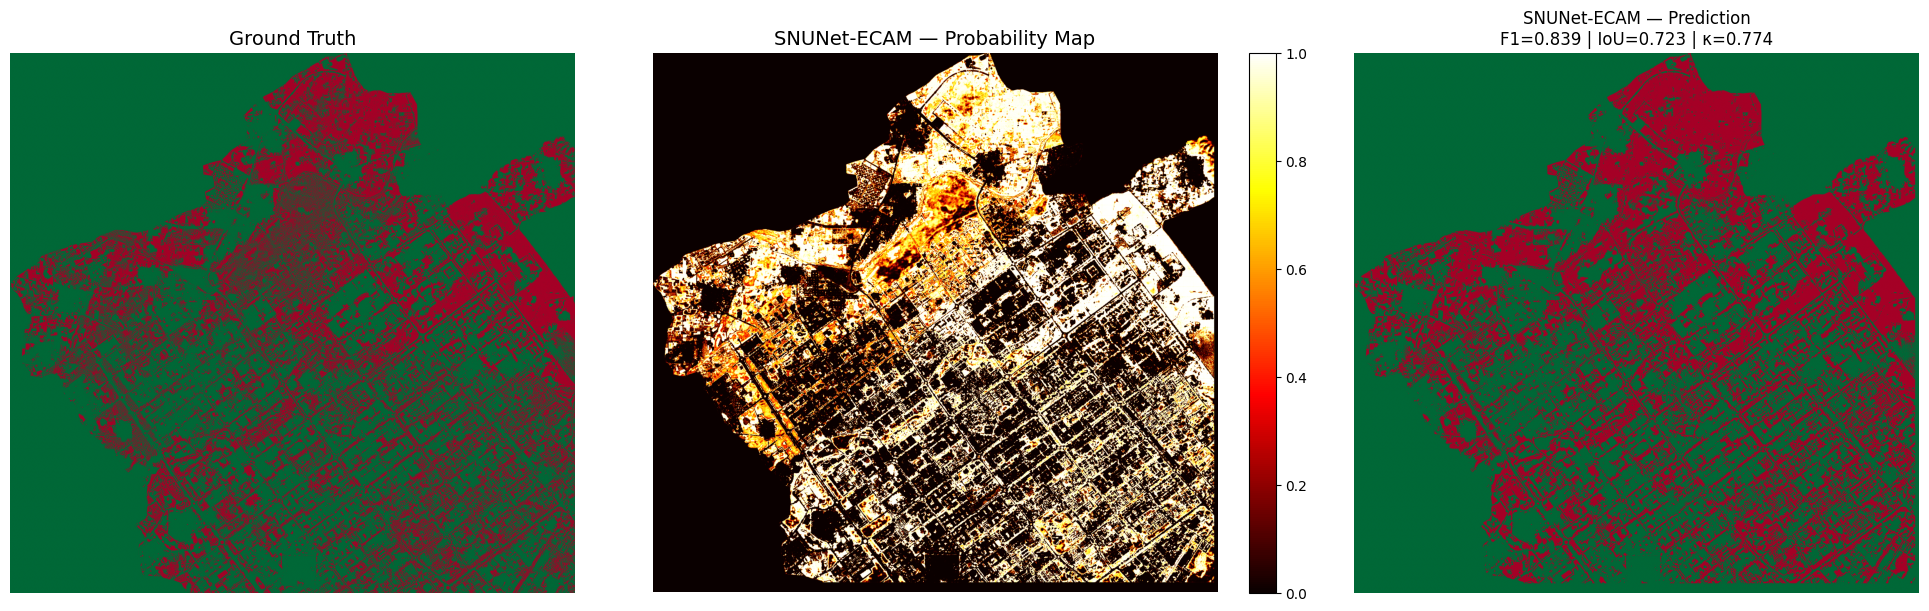


✅ All results saved to /content/outputs_siamese/


In [9]:
# ============================================================
# CELL 9: FINAL EVALUATION & VISUALIZATION
# ============================================================

gt   = mask.flatten().astype(int)
pred = binary_map.flatten().astype(int)
v = (gt >= 0) & (gt <= 1)

tp = np.sum((pred[v]==1) & (gt[v]==1))
fp = np.sum((pred[v]==1) & (gt[v]==0))
fn = np.sum((pred[v]==0) & (gt[v]==1))
tn = np.sum((pred[v]==0) & (gt[v]==0))

prec = tp/(tp+fp) if tp+fp else 0
rec  = tp/(tp+fn) if tp+fn else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
iou  = tp/(tp+fp+fn) if tp+fp+fn else 0
oa   = (tp+tn) / v.sum()
kap  = cohen_kappa_score(gt[v], pred[v])

print('╔═══════════════════════════════════════════════════════╗')
print(f'║    FINAL RESULTS — {MODEL_CHOICE:^20s}            ║')
print('╠═══════════════════════════════════════════════════════╣')
print(f'║  Precision        : {prec:.4f}                          ║')
print(f'║  Recall           : {rec:.4f}                          ║')
print(f'║  F1-Score         : {f1:.4f}                          ║')
print(f'║  IoU              : {iou:.4f}                          ║')
print(f'║  Overall Accuracy : {oa:.4f}                          ║')
print(f'║  Kappa Coefficient: {kap:.4f}                          ║')
print(f'╠═══════════════════════════════════════════════════════╣')
print(f'║  Changed area     : {binary_map.sum()*9/10000:>10,.1f} ha                ║')
print(f'║  Total area       : {binary_map.size*9/10000:>10,.1f} ha                ║')
print(f'║  Change %         : {binary_map.mean()*100:>10.1f}%                 ║')
print('╚═══════════════════════════════════════════════════════╝')

# Save report
report = {
    'model': MODEL_CHOICE,
    'temporal': '2016 → 2025',
    'resolution_m': 3,
    'best_epoch': ckpt['epoch'],
    'metrics': {
        'precision': round(prec, 4), 'recall': round(rec, 4),
        'f1': round(f1, 4), 'iou': round(iou, 4),
        'oa': round(oa, 4), 'kappa': round(kap, 4)
    },
    'area': {
        'changed_ha': round(binary_map.sum()*9/10000, 1),
        'total_ha': round(binary_map.size*9/10000, 1)
    }
}
with open(os.path.join(OUTPUT_DIR, 'evaluation_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].imshow(mask, cmap='RdYlGn_r')
ax[0].set_title('Ground Truth', fontsize=14)
ax[0].axis('off')

im = ax[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
ax[1].set_title(f'{MODEL_CHOICE} — Probability Map', fontsize=14)
ax[1].axis('off')
plt.colorbar(im, ax=ax[1], fraction=0.046)

ax[2].imshow(binary_map, cmap='RdYlGn_r')
ax[2].set_title(f'{MODEL_CHOICE} — Prediction\nF1={f1:.3f} | IoU={iou:.3f} | κ={kap:.3f}', fontsize=12)
ax[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'results_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ All results saved to {OUTPUT_DIR}/')

In [10]:
# ============================================================
# CELL 10: DOWNLOAD RESULTS
# ============================================================
from google.colab import files
import shutil

print('📁 Output files:\n')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, f)
    print(f'  📄 {f:40s} ({os.path.getsize(fp)/1e6:.1f} MB)')

zip_path = '/content/siamese_unet_results'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f'\n📦 Zipped → siamese_unet_results.zip')
files.download(f'{zip_path}.zip')
print('\n✅ Download triggered.')

📁 Output files:

  📄 best_siamese_unet.pth                    (48.2 MB)
  📄 change_prediction.tif                    (1.8 MB)
  📄 change_probability.tif                   (54.0 MB)
  📄 evaluation_report.json                   (0.0 MB)
  📄 results_comparison.png                   (3.5 MB)
  📄 training_curves.png                      (0.2 MB)
  📄 training_history.json                    (0.0 MB)

📦 Zipped → siamese_unet_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download triggered.
